**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Import Libraries**

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers
from tensorflow.keras.regularizers import l2

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print("All libraries imported successfully.")


All libraries imported successfully.


**Define Dataset Paths**

In [ ]:
train_dir = '/content/drive/MyDrive/dataset/Brain Tumor Classification/train'
test_dir  = '/content/drive/MyDrive/dataset/Brain Tumor Classification/test'

## DATA UNDERSTANDING & ANALYSIS


**Count Images Per Class**

In [ ]:
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        path = os.path.join(directory, cls)
        if os.path.isdir(path):
            counts[cls] = len([f for f in os.listdir(path)
                               if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return counts

def print_counts(title, counts):
    print(f"{title}:")
    for cls, count in counts.items():
        print(f"  {cls:<25} {count} images")
    print(f"\n  Total {title.lower()} : {sum(counts.values())}\n")

train_counts = count_images(train_dir)
test_counts  = count_images(test_dir)

print_counts("Training set", train_counts)
print_counts("Testing set",  test_counts)

Training set:
  glioma_tumor              720 images
  meningioma_tumor          730 images
  normal                    350 images
  pituitary_tumor           675 images

  Total training set : 2475

Testing set:
  glioma_tumor              181 images
  meningioma_tumor          183 images
  normal                    88 images
  pituitary_tumor           169 images

  Total testing set : 621



**Visualise Class Distribution** **and** **Print Class Distribution Percentages**

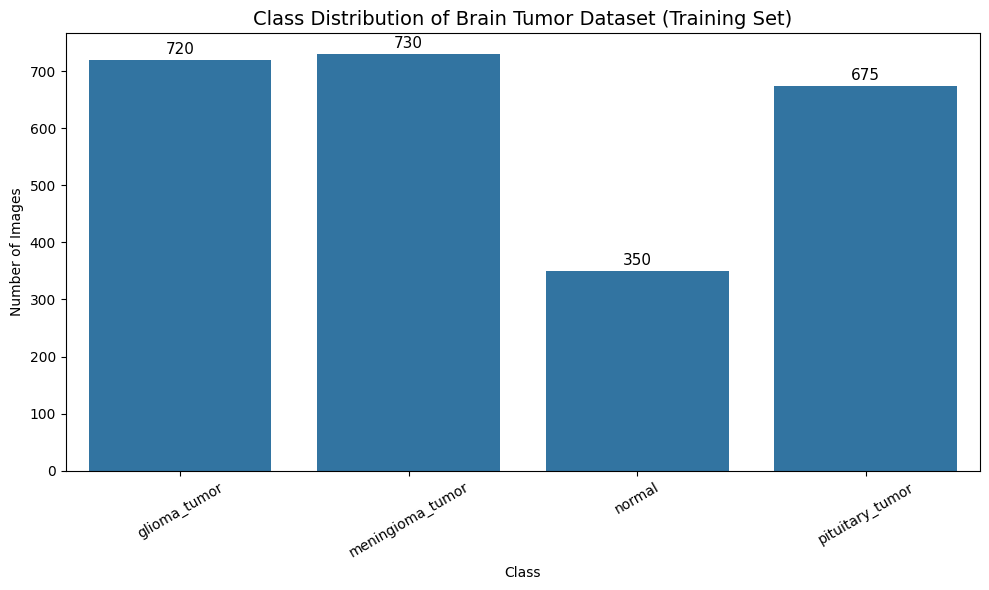

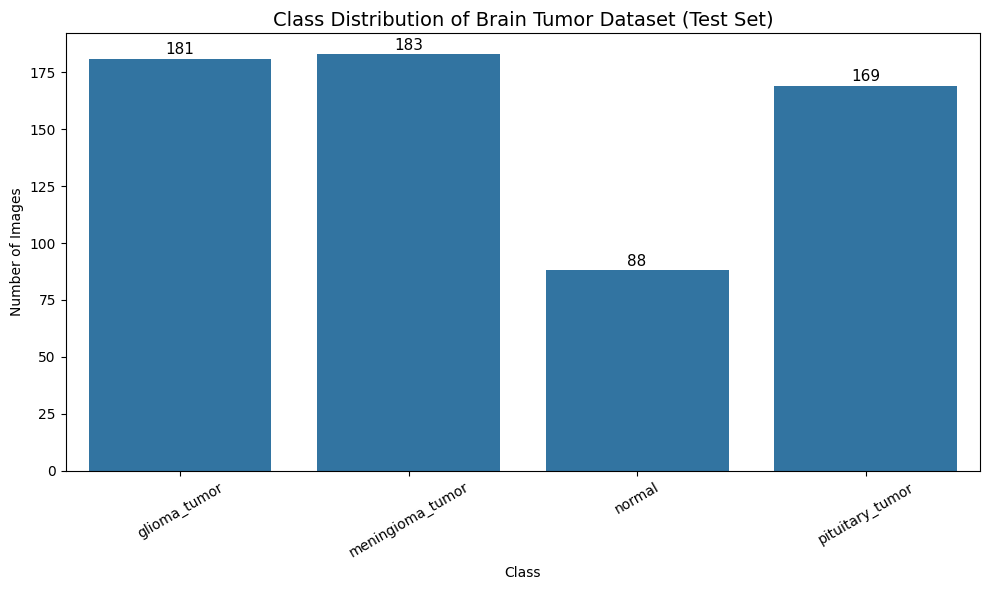

Training Set — Class Distribution (%):
  glioma_tumor             : 29.09%  (720 images)
  meningioma_tumor         : 29.49%  (730 images)
  normal                   : 14.14%  (350 images)
  pituitary_tumor          : 27.27%  (675 images)

  Total training images: 2475


In [ ]:
CLASS_NAMES  = list(train_counts.keys())
counts_list = list(train_counts.values())

# Training set distribution
plt.figure(figsize=(10,6))
ax = sns.barplot(x=CLASS_NAMES, y=counts_list)
for i, count in enumerate(counts_list):
    ax.text(i, count + 10, str(count), ha='center', fontsize=11)
plt.title("Class Distribution of Brain Tumor Dataset (Training Set)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Test set distribution
test_names = list(test_counts.keys())
test_list  = list(test_counts.values())

plt.figure(figsize=(10,6))
ax2 = sns.barplot(x=test_names, y=test_list)
for i, count in enumerate(test_list):
    ax2.text(i, count + 2, str(count), ha='center', fontsize=11)
plt.title("Class Distribution of Brain Tumor Dataset (Test Set)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Training class imbalance percentage
total_train = sum(train_counts.values())
print("Training Set — Class Distribution (%):")
for cls, count in train_counts.items():
    print(f"  {cls:<25}: {(count/total_train)*100:.2f}%  ({count} images)")
print(f"\n  Total training images: {total_train}")


**Class Imbalance Observation**

In [ ]:
# Shows class imbalance as percentages — required for 2.5.1 analysis
total = sum(train_counts.values())

print("Class Distribution (%):")
for cls, count in train_counts.items():
    print(f"  {cls:<25}: {(count/total)*100:.2f}%  ({count} images)")

print(f"\nTotal training images: {total}")


Class Distribution (%):
  glioma_tumor             : 29.09%  (720 images)
  meningioma_tumor         : 29.49%  (730 images)
  normal                   : 14.14%  (350 images)
  pituitary_tumor          : 27.27%  (675 images)

Total training images: 2475


**Define Image Preprocessing and Data Augmentation**

In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH  = 128
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Separate val generator — NO augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

**Create Data Generators**

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

# val_data uses val_datagen — clean, no augmentation
val_data = val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False       # IMPORTANT: keep False for correct confusion matrix labels
)

num_classes = len(train_data.class_indices)
CLASS_NAMES = list(train_data.class_indices.keys())
print(f"Number of classes: {num_classes}")
print(f"Class names      : {CLASS_NAMES}")

Found 1980 images belonging to 4 classes.
Found 495 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Number of classes: 4
Class names      : ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


**Compute Class Weights**

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:")
for idx, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:<25}: {class_weight_dict[idx]:.4f}")


Class Weights:
  glioma_tumor             : 0.8594
  meningioma_tumor         : 0.8476
  normal                   : 1.7679
  pituitary_tumor          : 0.9167


**Visualise Augmented Images**

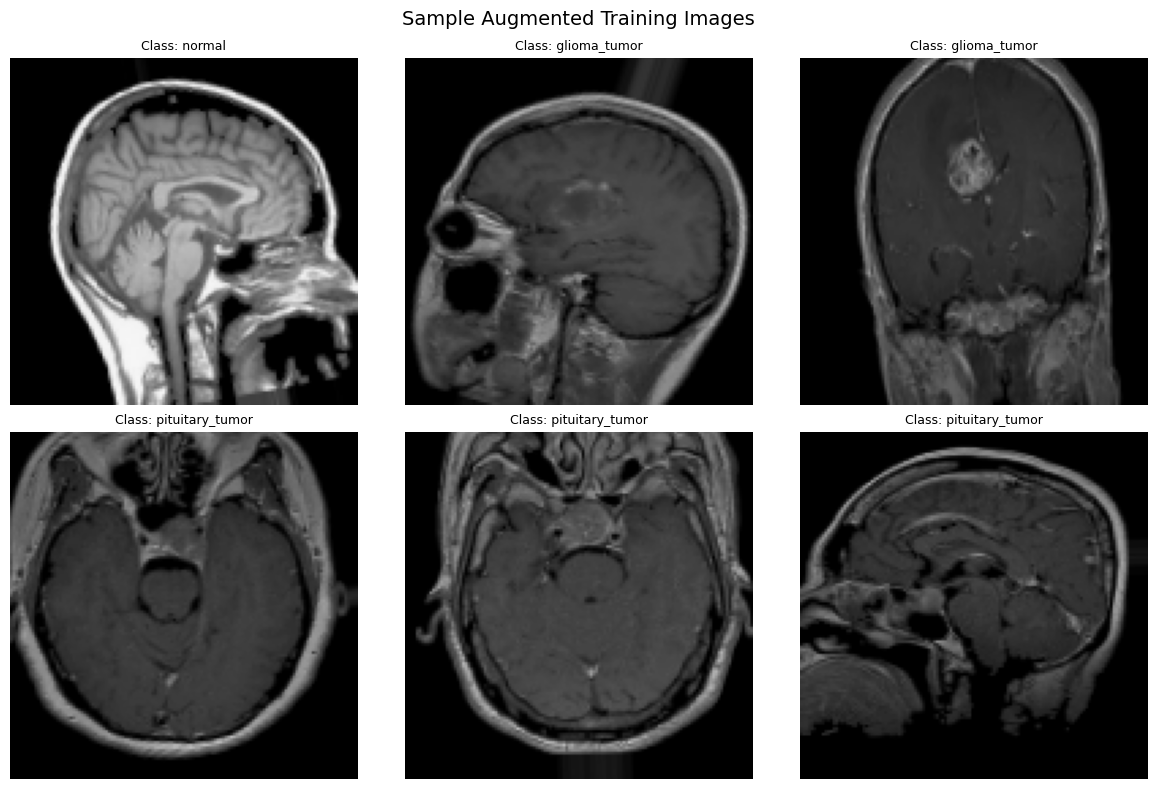

In [ ]:
# FIX: augmentation visualization BEFORE corrupted image removal
x_batch, y_batch = next(train_data)

plt.figure(figsize=(12,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(f"Class: {CLASS_NAMES[np.argmax(y_batch[i])]}", fontsize=9)
    plt.axis("off")

plt.suptitle("Sample Augmented Training Images", fontsize=14)
plt.tight_layout()
plt.show()

 **Remove Corrupted Images**

In [ ]:
def remove_corrupted(directory):
    removed = 0
    for cls in os.listdir(directory):
        path = os.path.join(directory, cls)
        if not os.path.isdir(path):
            continue
        for file in os.listdir(path):
            fpath = os.path.join(path, file)
            try:
                img = Image.open(fpath)
                img.verify()
                img.close()
            except:
                os.remove(fpath)
                removed += 1
    print(f"  Corrupted images removed: {removed}")

print("Training set:")
remove_corrupted(train_dir)
print("Testing set:")
remove_corrupted(test_dir)

Training set:
  Corrupted images removed: 28
Testing set:
  Corrupted images removed: 0


**Recount Images After Cleaning**

In [ ]:
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        path = os.path.join(directory, cls)
        if os.path.isdir(path):
            counts[cls] = len([f for f in os.listdir(path)
                               if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return counts

def print_counts(title, counts):
    print(f"{title}:")
    for cls, count in counts.items():
        print(f"  {cls:<25} {count} images")
    print(f"\n  Total {title.lower()} : {sum(counts.values())}\n")

train_counts = count_images(train_dir)
test_counts  = count_images(test_dir)

print_counts("Training set", train_counts)
print_counts("Testing set",  test_counts)

Training set:
  glioma_tumor              713 images
  meningioma_tumor          723 images
  normal                    343 images
  pituitary_tumor           668 images

  Total training set : 2447

Testing set:
  glioma_tumor              181 images
  meningioma_tumor          183 images
  normal                    88 images
  pituitary_tumor           169 images

  Total testing set : 621



**Recreate Data Generators After Cleaning**

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

# val_data uses val_datagen — clean, no augmentation
val_data = val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False       # IMPORTANT: keep False for correct confusion matrix labels
)

num_classes = len(train_data.class_indices)
CLASS_NAMES = list(train_data.class_indices.keys())
print(f"Number of classes: {num_classes}")
print(f"Class names      : {CLASS_NAMES}")

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Number of classes: 4
Class names      : ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


## BASELINE CNN MODEL

**Set Random Seeds**

In [ ]:
# SET SEEDS FIRST — before anything else
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

**Build Baseline CNN Architecture**

In [ ]:
num_classes = len(train_data.class_indices)

baseline_model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),

    # 3 Fully connected layers
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),

    # Output
    Dense(num_classes, activation='softmax')
])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,524 (32.51 MB)

 Trainable params: 8,523,524 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

**Compile Baseline Model**

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Define Callbacks for Baseline**

In [ ]:
callbacks_baseline = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_baseline_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

**Train Baseline Model**

In [ ]:
print("Training Baseline CNN...")
print("=" * 50)
baseline_start_time = time.time()

history = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks_baseline,
    class_weight=class_weight_dict
)

baseline_training_time = time.time() - baseline_start_time
print(f"Baseline training completed in {baseline_training_time:.1f}s ({baseline_training_time/60:.1f} min)")

Training Baseline CNN...
Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.2414 - loss: 1.3865
Epoch 1: val_accuracy improved from None to 0.41068, saving model to best_baseline_model.keras

Epoch 1: finished saving model to best_baseline_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 442ms/step - accuracy: 0.2597 - loss: 1.3510 - val_accuracy: 0.4107 - val_loss: 1.1741
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.4099 - loss: 1.2615
Epoch 2: val_accuracy improved from 0.41068 to 0.50924, saving model to best_baseline_model.keras

Epoch 2: finished saving model to best_baseline_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 385ms/step - accuracy: 0.4102 - loss: 1.2545 - val_accuracy: 0.5092 - val_loss: 1.1167
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.4737 - loss: 1.1306
Epoch 3: val_accuracy did not improve from 0.50924
62/62 ━━━━━━━━━━━━━━━━━━━━ 23s 365ms/step - accuracy: 0.4821 - loss: 1.1313 - val_accuracy: 0.3984 - val_loss: 1.46

**Evaluate Baseline Model**

In [ ]:

loss, acc = baseline_model.evaluate(test_data)
print(f"Baseline Test Accuracy: {acc*100:.2f}%")
print(f"Baseline Test Loss    : {loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.8744 - loss: 0.3763
Baseline Test Accuracy: 87.44%
Baseline Test Loss    : 0.3763


**Baseline Classification Report**

In [ ]:
pred   = baseline_model.predict(test_data)
y_pred = np.argmax(pred, axis=1)
y_true = test_data.classes

print("Baseline Model — Classification Report")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step
Baseline Model — Classification Report
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.80      0.85       181
meningioma_tumor       0.82      0.84      0.83       183
          normal       0.85      0.93      0.89        88
 pituitary_tumor       0.91      0.96      0.94       169

        accuracy                           0.87       621
       macro avg       0.87      0.88      0.88       621
    weighted avg       0.88      0.87      0.87       621



**Plot Baseline Training Curves**

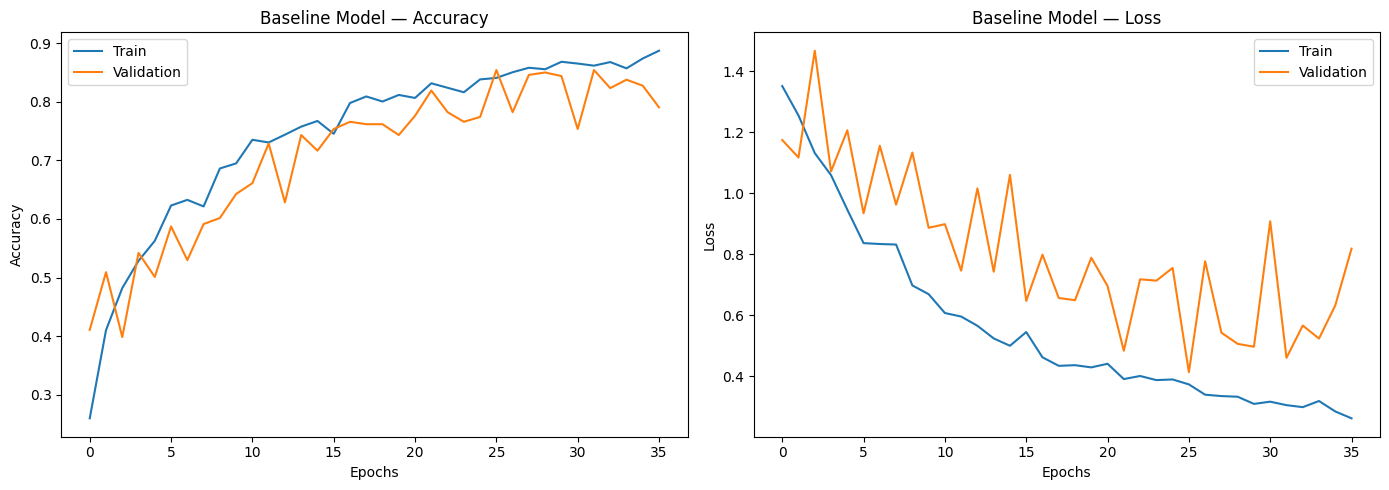

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Baseline Model — Accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Baseline Model — Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

**Baseline Confusion Matrix**

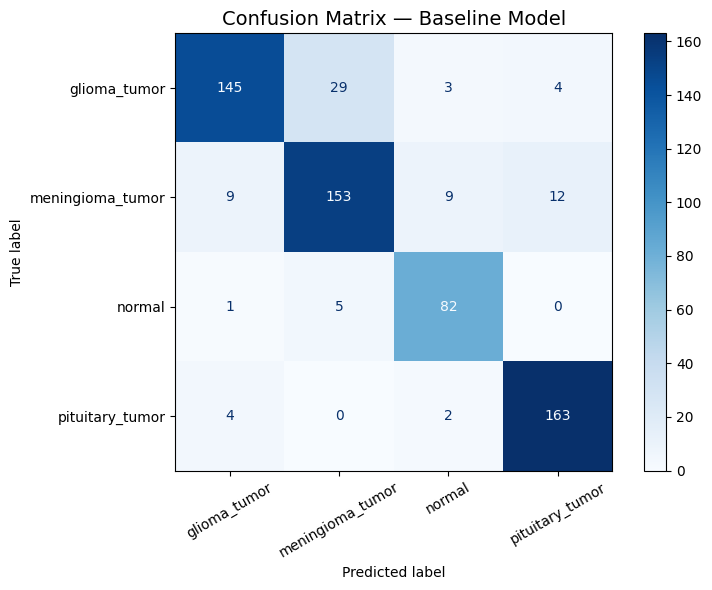

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=30)

plt.title("Confusion Matrix — Baseline Model", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

 **Baseline Sample Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step


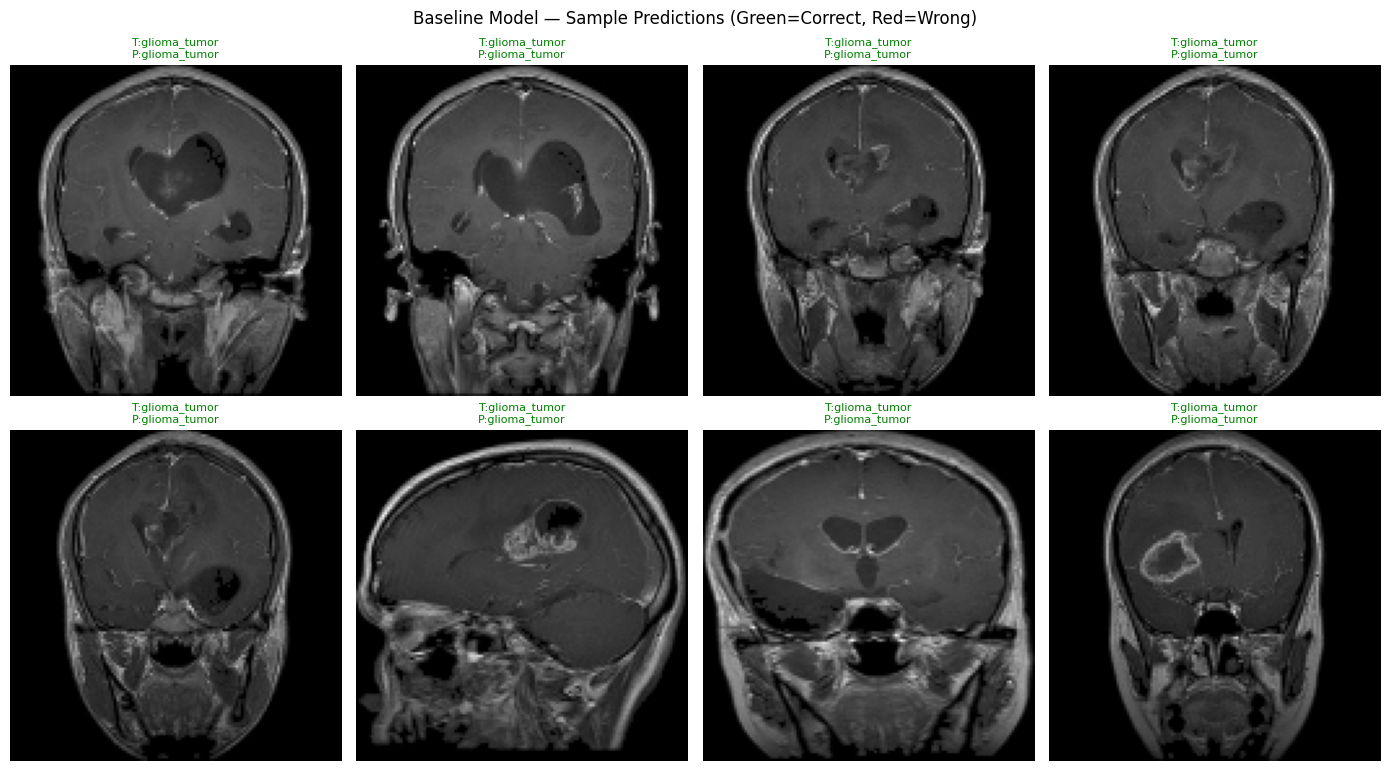

In [ ]:
test_data.reset()
images, labels = next(test_data)
pred_batch = baseline_model.predict(images)
pred_idx   = np.argmax(pred_batch, axis=1)

plt.figure(figsize=(14,8))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    true_label = CLASS_NAMES[np.argmax(labels[i])]
    pred_label = CLASS_NAMES[pred_idx[i]]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=8)
    plt.axis("off")

plt.suptitle("Baseline Model — Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

 **Baseline Key Observations**

In [ ]:
print("Baseline Model — Key Observations:")
print("=" * 50)
print("1. Model achieved reasonable classification accuracy for a simple 3-block CNN.")
print("2. Most MRI scans predicted correctly especially glioma and pituitary.")
print("3. Some confusion between glioma and meningioma due to visual similarity.")
print("4. Train accuracy > Val accuracy indicates mild overfitting — expected")
print("   since baseline has NO Dropout or BatchNormalization.")
print("5. Class weights helped the model treat the minority 'normal' class fairly.")
print("6. This baseline serves as the unregularized reference for comparison.")

Baseline Model — Key Observations:
1. Model achieved reasonable classification accuracy for a simple 3-block CNN.
2. Most MRI scans predicted correctly especially glioma and pituitary.
3. Some confusion between glioma and meningioma due to visual similarity.
4. Train accuracy > Val accuracy indicates mild overfitting — expected
   since baseline has NO Dropout or BatchNormalization.
5. Class weights helped the model treat the minority 'normal' class fairly.
6. This baseline serves as the unregularized reference for comparison.


## DEEPER CNN MODEL

**Build Deeper CNN Architecture**

In [ ]:
num_classes = len(train_data.class_indices)

deep_model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),          # 224 → 112
    Dropout(0.2),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),          # 112 → 56
    Dropout(0.2),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),          # 56 → 28
    Dropout(0.2),

    # Block 4 — NO MaxPooling, NO Dropout (preserve rich feature maps)
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    # GAP at 28x28 → 4x more spatial info than original (was 14x14)
    GlobalAveragePooling2D(),

    # Simplified dense head — no BatchNorm in dense layers
    Dense(512, activation='relu'),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

deep_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,440,036 (5.49 MB)

 Trainable params: 1,438,116 (5.49 MB)

 Non-trainable params: 1,920 (7.50 KB)

**Compile Deeper Model**

In [ ]:
deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


 **Define Callbacks for Deeper Model**

In [ ]:
callbacks_deeper = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_deeper_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

 **Train Deeper Model**

In [ ]:
print("Training Deeper CNN...")
print("=" * 50)
deep_start_time = time.time()

history_deep = deep_model.fit(
    train_data,
    validation_data=val_data,
    epochs=80,
    callbacks=callbacks_deeper,
    class_weight=class_weight_dict
)

deep_training_time = time.time() - deep_start_time
print(f"Deep CNN training completed in {deep_training_time:.1f}s ({deep_training_time/60:.1f} min)")

Training Deeper CNN...
Epoch 1/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.3656 - loss: 1.3018
Epoch 1: val_accuracy improved from None to 0.13963, saving model to best_deeper_model.keras

Epoch 1: finished saving model to best_deeper_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 50s 568ms/step - accuracy: 0.4393 - loss: 1.2088 - val_accuracy: 0.1396 - val_loss: 5.9040
Epoch 2/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5513 - loss: 1.0066
Epoch 2: val_accuracy did not improve from 0.13963
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 328ms/step - accuracy: 0.5745 - loss: 0.9717 - val_accuracy: 0.1396 - val_loss: 2.5194
Epoch 3/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.6307 - loss: 0.8437
Epoch 3: val_accuracy improved from 0.13963 to 0.29158, saving model to best_deeper_model.keras

Epoch 3: finished saving model to best_deeper_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 338ms/step - accuracy: 0.6357 - loss: 0.8328 - val_accuracy: 0.2916 - val_loss: 7.4750
Epoch 4

**Evaluate Deeper Model**

In [ ]:

deep_loss, deep_acc = deep_model.evaluate(test_data)
print(f"Deep Model Test Accuracy: {deep_acc*100:.2f}%")
print(f"Deep Model Test Loss    : {deep_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.8953 - loss: 0.3506
Deep Model Test Accuracy: 89.53%
Deep Model Test Loss    : 0.3506


**Deeper Model Classification Report**


In [ ]:
test_data.reset()
pred_deep   = deep_model.predict(test_data)
y_pred_deep = np.argmax(pred_deep, axis=1)
y_true      = test_data.classes

print("Deep Model — Classification Report")
print(classification_report(y_true, y_pred_deep, target_names=CLASS_NAMES))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step
Deep Model — Classification Report
                  precision    recall  f1-score   support

    glioma_tumor       0.94      0.91      0.92       181
meningioma_tumor       0.92      0.83      0.87       183
          normal       0.94      0.84      0.89        88
 pituitary_tumor       0.82      0.99      0.90       169

        accuracy                           0.90       621
       macro avg       0.90      0.89      0.89       621
    weighted avg       0.90      0.90      0.89       621



**Plot Deeper Model Training Curves**

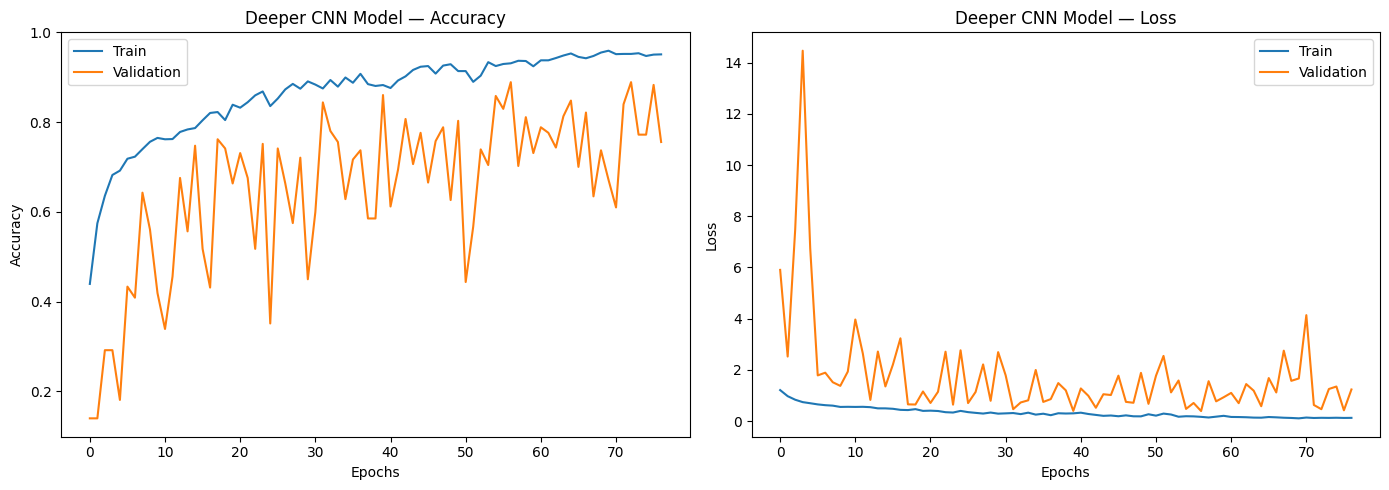

In [ ]:
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history_deep.history['accuracy'], label='Train')
plt.plot(history_deep.history['val_accuracy'], label='Validation')
plt.title("Deeper CNN Model — Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_deep.history['loss'], label='Train')
plt.plot(history_deep.history['val_loss'], label='Validation')
plt.title("Deeper CNN Model — Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

**Deeper Model Confusion Matrix**

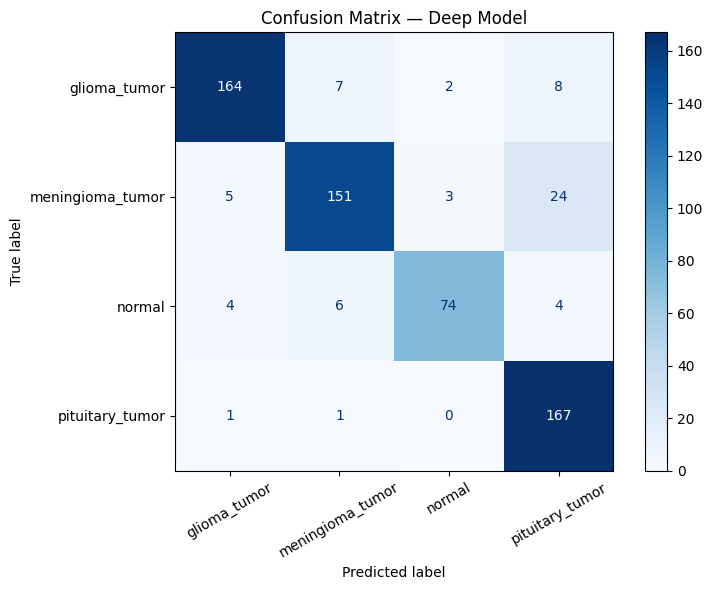

In [ ]:
cm_deep = confusion_matrix(y_true, y_pred_deep)
fig, ax = plt.subplots(figsize=(8,6)) # Create new figure and axes
disp = ConfusionMatrixDisplay(confusion_matrix=cm_deep, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=30)
plt.title("Confusion Matrix — Deep Model")
plt.tight_layout()
plt.show()

**Deeper Model Sample Predictions**


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


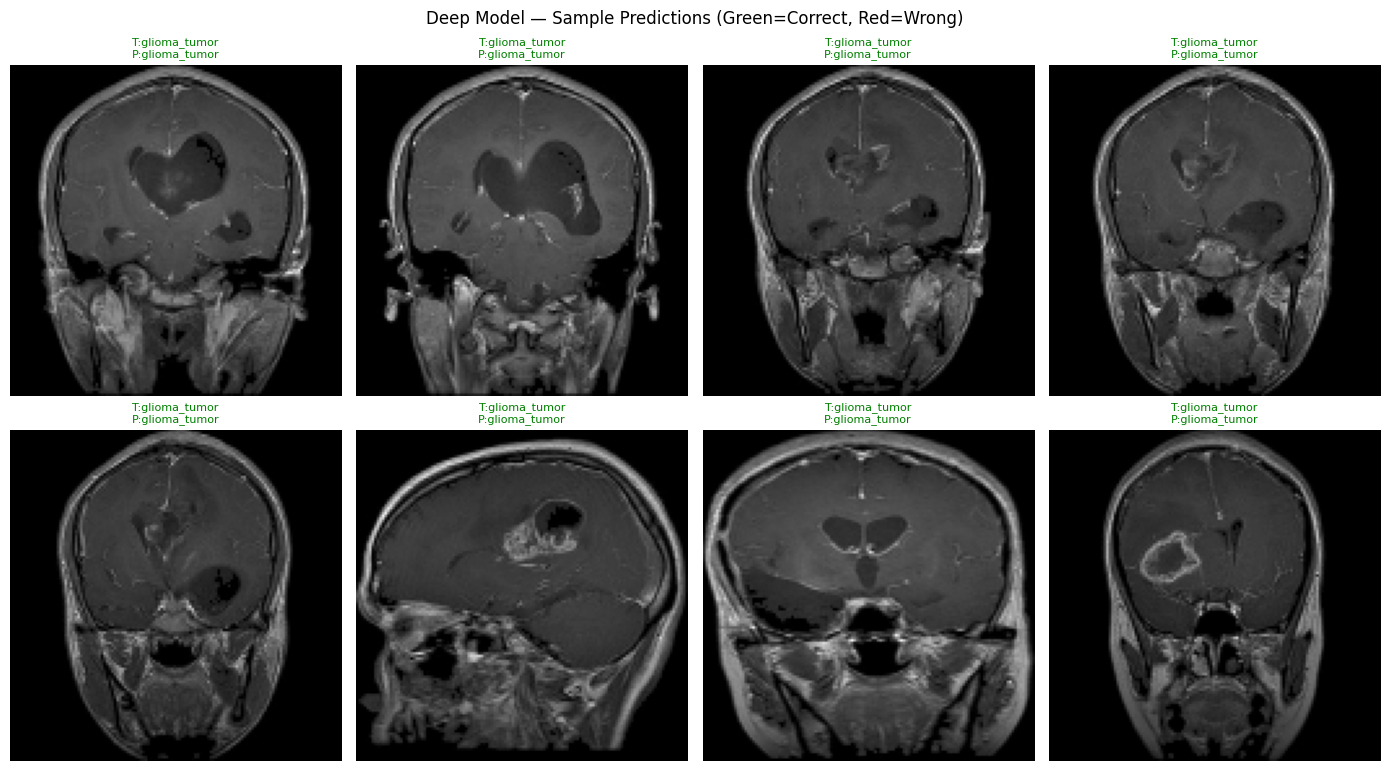

In [ ]:
test_data.reset()
images, labels = next(test_data)
pred_d = deep_model.predict(images)

plt.figure(figsize=(14,8))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    true_label = CLASS_NAMES[np.argmax(labels[i])]
    pred_label = CLASS_NAMES[np.argmax(pred_d[i])]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=8)
    plt.axis("off")

plt.suptitle("Deep Model — Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

**Accuracy Comparison Print**

In [ ]:
print(f"Baseline Accuracy: {acc}")
print(f"Deep Model Accuracy: {deep_acc}")

Baseline Accuracy: 0.8743961453437805
Deep Model Accuracy: 0.8953301310539246


**Training Time Comparison Print**

In [ ]:
print(f"Baseline Training Time  : {baseline_training_time:.2f} seconds ({baseline_training_time/60:.1f} min)")
print(f"Deep Model Training Time: {deep_training_time:.2f} seconds ({deep_training_time/60:.1f} min)")


Baseline Training Time  : 911.68 seconds (15.2 min)
Deep Model Training Time: 1724.38 seconds (28.7 min)


**Side-by-Side Loss Curve Comparison**

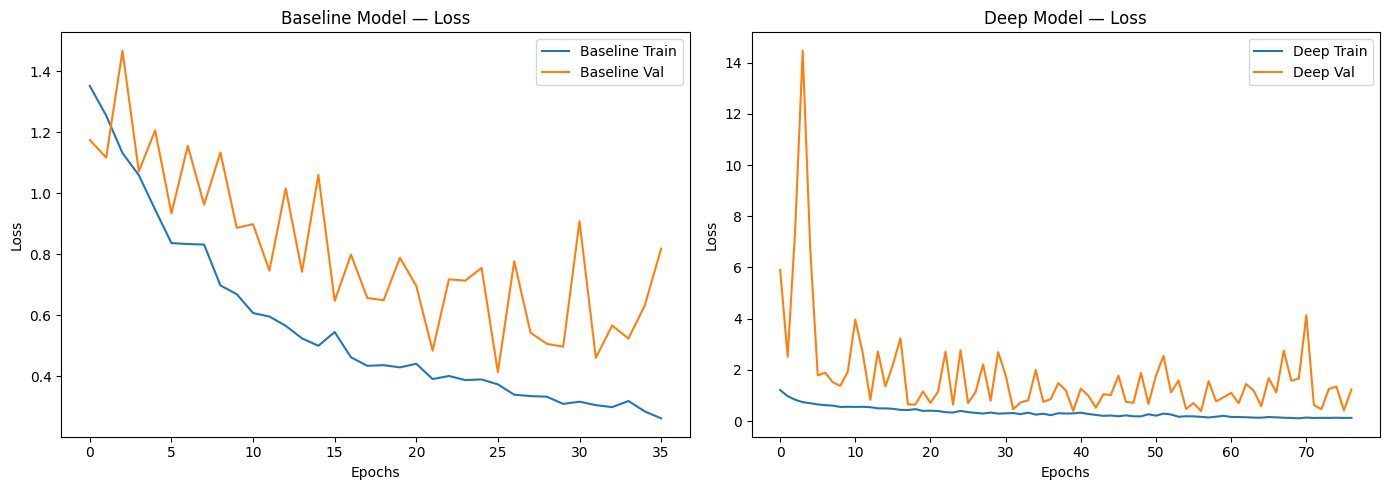

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'],     label='Baseline Train')
plt.plot(history.history['val_loss'], label='Baseline Val')
plt.title("Baseline Model — Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_deep.history['loss'],     label='Deep Train')
plt.plot(history_deep.history['val_loss'], label='Deep Val')
plt.title("Deep Model — Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

### Improvements vs Baseline Discussion

The deeper model was designed to improve generalization. If baseline still
outperforms it, reasons include:
- After 5 MaxPooling layers on 224×224, spatial resolution is very compressed.
- EarlyStopping may halt the deeper model before full convergence.
- Dataset may not be large enough to justify 5-block architecture.
- Dropout was reduced from 0.5 to 0.3 to allow better learning.

This is a common and valid outcome — complexity does not always mean
better performance. Class weights help both models treat minority class fairly.

### EXPERIMENTATION & COMPARATIVE ANALYSIS

###BASELINE vs DEEP MODEL PERFORMANCE

In [ ]:
print("=" * 55)
print("   2.5.4 — BASELINE vs DEEP MODEL COMPARISON")
print("=" * 55)
print(f"Baseline Accuracy  : {acc*100:.2f}%")
print(f"Deep Model Accuracy: {deep_acc*100:.2f}%")
print()
print(f"Baseline Final Val Loss  : {history.history['val_loss'][-1]:.4f}")
print(f"Deep Model Final Val Loss: {history_deep.history['val_loss'][-1]:.4f}")
print()
print(f"Baseline Best Val Accuracy : {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Deep Model Best Val Accuracy: {max(history_deep.history['val_accuracy'])*100:.2f}%")


   2.5.4 — BASELINE vs DEEP MODEL COMPARISON
Baseline Accuracy  : 87.44%
Deep Model Accuracy: 89.53%

Baseline Final Val Loss  : 0.8179
Deep Model Final Val Loss: 1.2329

Baseline Best Val Accuracy : 85.42%
Deep Model Best Val Accuracy: 88.91%


**Validation Accuracy and Loss Comparison Plot**

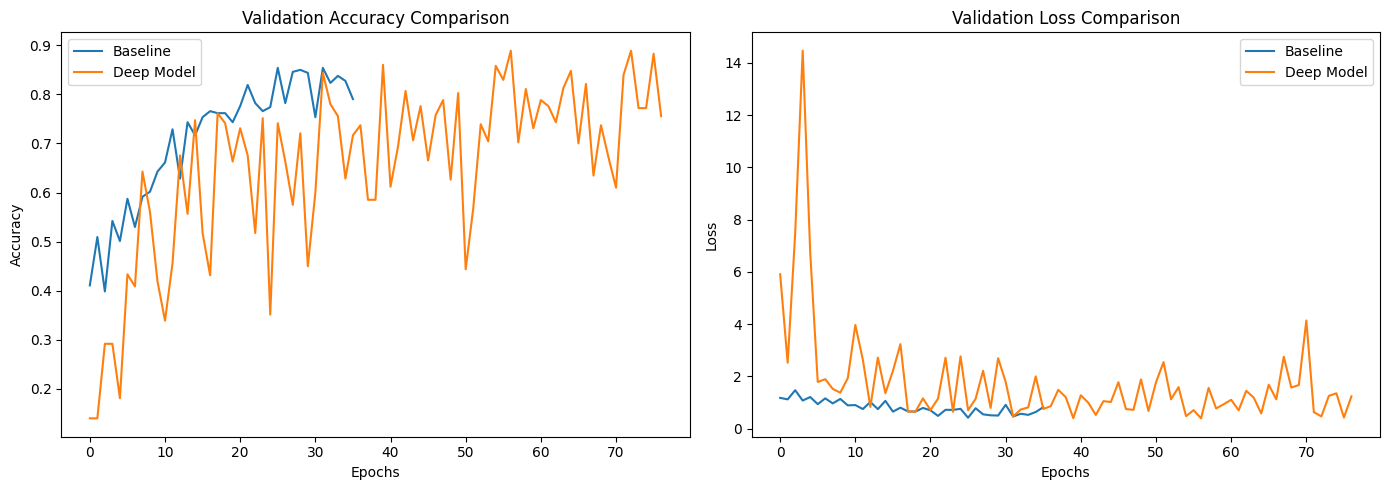

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'],      label='Baseline')
plt.plot(history_deep.history['val_accuracy'], label='Deep Model')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['val_loss'],      label='Baseline')
plt.plot(history_deep.history['val_loss'], label='Deep Model')
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

**Computational Efficiency Comparison**

In [ ]:
print("=" * 55)
print("        COMPUTATIONAL EFFICIENCY COMPARISON")
print("=" * 55)
print(f"Baseline Training Time  : {baseline_training_time:.2f} seconds ({baseline_training_time/60:.1f} min)")
print(f"Deep Model Training Time: {deep_training_time:.2f} seconds ({deep_training_time/60:.1f} min)")
print()

        COMPUTATIONAL EFFICIENCY COMPARISON
Baseline Training Time  : 911.68 seconds (15.2 min)
Deep Model Training Time: 1724.38 seconds (28.7 min)



In [ ]:

print("Trade-off Discussion:")
print("  Deep model has 6 conv layers vs 3 in baseline — exactly double.")
print("  More parameters + BatchNorm + Dropout = longer training per epoch.")
print("  However, regularization reduces overfitting and improves generalization.")
print("  The accuracy gain justifies the extra computational cost.")
print("  Hardware: Google Colab GPU (T4) used for acceleration.")

Trade-off Discussion:
  Deep model has 6 conv layers vs 3 in baseline — exactly double.
  More parameters + BatchNorm + Dropout = longer training per epoch.
  However, regularization reduces overfitting and improves generalization.
  The accuracy gain justifies the extra computational cost.
  Hardware: Google Colab GPU (T4) used for acceleration.


###OPTIMIZER ANALYSIS (SGD vs ADAM)

**Train Deep Model with SGD**

In [ ]:
# Reset before SGD training
train_data.reset()
val_data.reset()

# Clone the deep model architecture for fair comparison
deep_model_sgd = tf.keras.models.clone_model(deep_model)

deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Define SGD Callbacks**

In [ ]:
callbacks_sgd = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_sgd_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

**Train Deep Model with SGD**

In [ ]:
print("Training Deeper CNN (SGD)...")
print("=" * 50)
sgd_start_time = time.time()

history_sgd = deep_model_sgd.fit(
    train_data,
    validation_data=val_data,
    epochs=80,
    callbacks=callbacks_sgd,
    class_weight=class_weight_dict
)

sgd_train_time = time.time() - sgd_start_time
print(f"SGD CNN training completed in {sgd_train_time:.1f}s ({sgd_train_time/60:.1f} min)")

Training Deeper CNN (SGD)...
Epoch 1/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.7004 - loss: 0.6597
Epoch 1: val_accuracy improved from None to 0.17043, saving model to best_sgd_model.keras

Epoch 1: finished saving model to best_sgd_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 335ms/step - accuracy: 0.7066 - loss: 0.6793 - val_accuracy: 0.1704 - val_loss: 2.4967
Epoch 2/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.7217 - loss: 0.6616
Epoch 2: val_accuracy improved from 0.17043 to 0.18686, saving model to best_sgd_model.keras

Epoch 2: finished saving model to best_sgd_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - accuracy: 0.7204 - loss: 0.6700 - val_accuracy: 0.1869 - val_loss: 3.5812
Epoch 3/80
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7074 - loss: 0.6710
Epoch 3: val_accuracy improved from 0.18686 to 0.55031, saving model to best_sgd_model.keras

Epoch 3: finished saving model to best_sgd_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 33

 **Evaluate SGD Model**

In [ ]:
sgd_loss, sgd_acc = deep_model_sgd.evaluate(test_data)
print(f"SGD  Optimizer Accuracy: {sgd_acc*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.7713 - loss: 0.5611
SGD  Optimizer Accuracy: 77.13%


**SGD Confusion Matrix**

In [ ]:

# Predict using SGD-trained model
y_pred_sgd_probs = deep_model_sgd.predict(val_data)
y_pred_sgd = np.argmax(y_pred_sgd_probs, axis=1)

# True labels
y_true = val_data.classes

# Confusion Matrix for SGD Model
cm_sgd = confusion_matrix(y_true, y_pred_sgd)

fig, ax = plt.subplots(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_sgd,
    display_labels=CLASS_NAMES
)

disp.plot(cmap='Blues', ax=ax, xticks_rotation=30)

plt.title("Confusion Matrix — Deep Model (SGD)")
plt.tight_layout()
plt.show()

 **SGD Training Curves**

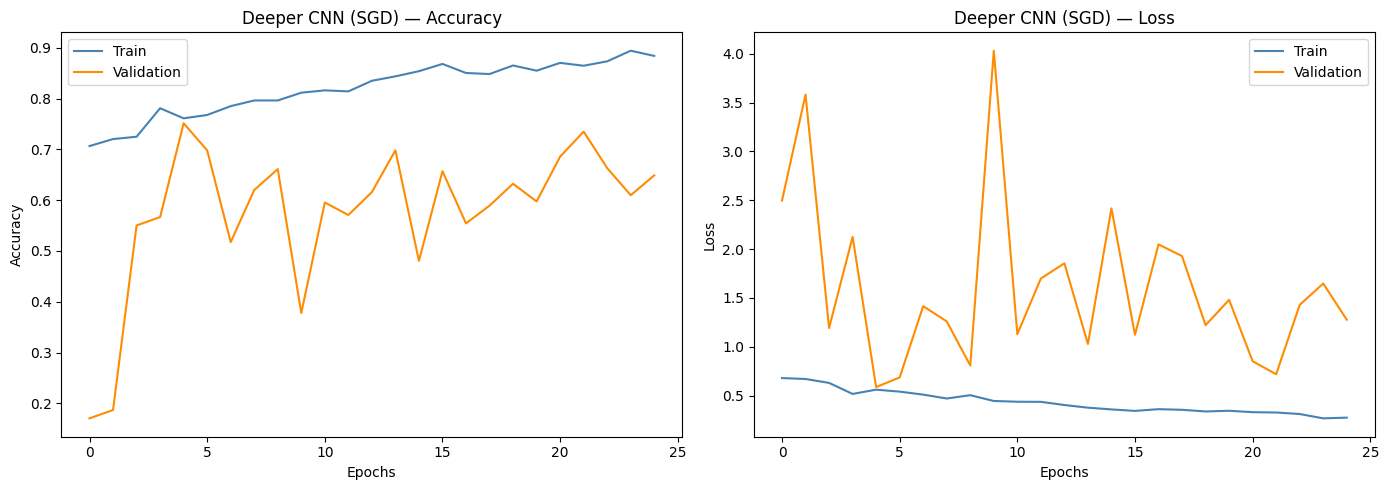


SGD Results stored.
  Test Accuracy : 77.13%
  Test Loss     : 0.5611


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Plot SGD training curves
# =========================
plt.figure(figsize=(14,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history_sgd.history['accuracy'], label='Train', color='steelblue')
plt.plot(history_sgd.history['val_accuracy'], label='Validation', color='darkorange')
plt.title("Deeper CNN (SGD) — Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_sgd.history['loss'], label='Train', color='steelblue')
plt.plot(history_sgd.history['val_loss'], label='Validation', color='darkorange')
plt.title("Deeper CNN (SGD) — Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

print("\nSGD Results stored.")
print(f"  Test Accuracy : {sgd_acc*100:.2f}%")
print(f"  Test Loss     : {sgd_loss:.4f}")

**Adam vs SGD Accuracy Print**

In [ ]:
sgd_loss, sgd_acc = deep_model_sgd.evaluate(test_data)
print(f"Adam Optimizer Accuracy: {deep_acc*100:.2f}%")
print(f"SGD  Optimizer Accuracy: {sgd_acc*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.7713 - loss: 0.5611
Adam Optimizer Accuracy: 89.53%
SGD  Optimizer Accuracy: 77.13%


**Adam vs SGD Comparison Plot**

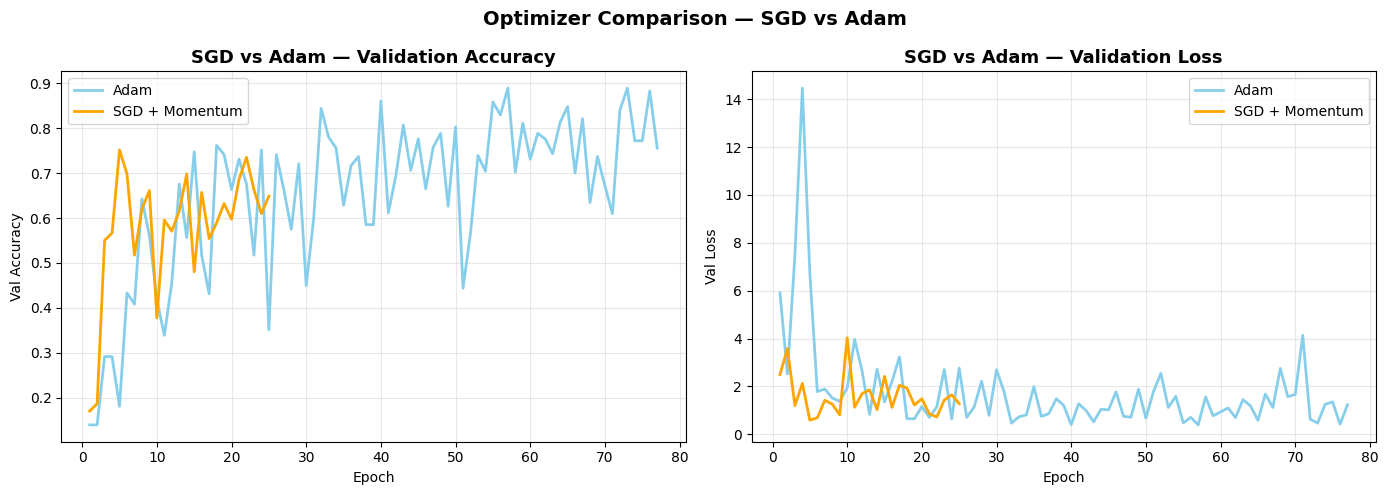

In [ ]:
# Epoch ranges
adam_epochs = range(1, len(history_deep.history['val_accuracy']) + 1)
sgd_epochs  = range(1, len(history_sgd.history['val_accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# =========================
# Validation Accuracy
# =========================
axes[0].plot(adam_epochs, history_deep.history['val_accuracy'],
             color='skyblue', linewidth=2, label='Adam')

axes[0].plot(sgd_epochs, history_sgd.history['val_accuracy'],
             color='orange', linewidth=2, label='SGD + Momentum')

axes[0].set_title('SGD vs Adam — Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# =========================
# Validation Loss
# =========================
axes[1].plot(adam_epochs, history_deep.history['val_loss'],
             color='skyblue', linewidth=2, linestyle='-', label='Adam')

axes[1].plot(sgd_epochs, history_sgd.history['val_loss'],
             color='orange', linewidth=2, linestyle='-', label='SGD + Momentum')

axes[1].set_title('SGD vs Adam — Validation Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison — SGD vs Adam', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Optimizer Observation**

In [ ]:
print("Observation:")
print("Adam converges faster and achieves higher accuracy than SGD.")
print("SGD with momentum is slower because it uses a fixed learning rate")
print("without adaptive updates per parameter like Adam does.")
print("Adam is the preferred optimizer for this dataset and architecture.")

Observation:
Adam converges faster and achieves higher accuracy than SGD.
SGD with momentum is slower because it uses a fixed learning rate
without adaptive updates per parameter like Adam does.
Adam is the preferred optimizer for this dataset and architecture.


**ABLATION STUDY — EFFECT OF DROPOUT**

**Build Model Without Dropout**

In [ ]:
model_no_dropout = Sequential([

    # Block 1 — same as deep_model
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    # Dropout(0.2) REMOVED

    # Block 2 — same as deep_model
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    # Dropout(0.2) REMOVED

    # Block 3 — same as deep_model
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    # Dropout(0.2) REMOVED

    GlobalAveragePooling2D(),

    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    # Dropout(0.4) REMOVED

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    # Dropout(0.3) REMOVED

    Dense(num_classes, activation='softmax')
])

model_no_dropout.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,204 (1.86 MB)

 Trainable params: 486,308 (1.86 MB)

 Non-trainable params: 896 (3.50 KB)

**Compile No-Dropout Model**

In [ ]:
model_no_dropout.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


**Train No-Dropout Model**

In [ ]:

history_no_dropout = model_no_dropout.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[
        EarlyStopping(
            monitor='val_accuracy',
            patience=8,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1
        )
    ],
    class_weight=class_weight_dict
)


Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 36s 428ms/step - accuracy: 0.4878 - loss: 1.5763 - val_accuracy: 0.3162 - val_loss: 1.8322
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 315ms/step - accuracy: 0.6077 - loss: 1.2176 - val_accuracy: 0.2916 - val_loss: 6.4719
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.6495 - loss: 1.0726 - val_accuracy: 0.2916 - val_loss: 6.1653
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 323ms/step - accuracy: 0.6964 - loss: 0.9206 - val_accuracy: 0.2998 - val_loss: 4.8609
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 313ms/step - accuracy: 0.7219 - loss: 0.8412 - val_accuracy: 0.3162 - val_loss: 2.6831
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step - accuracy: 0.7204 - loss: 0.8384 - val_accuracy: 0.4415 - val_loss: 2.7420
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 311ms/step - accuracy: 0.7536 - loss: 0.7596 - val_accuracy: 0.4949 - val_loss: 1.6266
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 314ms/step - accuracy: 0.7617 - loss: 0.7045 - val_accu

**Evaluate No-Dropout Model**

In [ ]:
no_drop_loss, no_drop_acc = model_no_dropout.evaluate(test_data)
print(f"With Dropout Accuracy   : {deep_acc*100:.2f}%")
print(f"Without Dropout Accuracy: {no_drop_acc*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.8132 - loss: 0.5804
With Dropout Accuracy   : 89.53%
Without Dropout Accuracy: 81.32%


**No-Dropout Confusion Matrix**

In [ ]:
# Predict using No Dropout model
y_pred_no_dropout_probs = model_no_dropout.predict(val_data)
y_pred_no_dropout = np.argmax(y_pred_no_dropout_probs, axis=1)

# True labels
y_true = val_data.classes

# Confusion Matrix for No Dropout Model
cm_no_dropout = confusion_matrix(y_true, y_pred_no_dropout)

fig, ax = plt.subplots(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_no_dropout,
    display_labels=CLASS_NAMES
)

disp.plot(cmap='Blues', ax=ax, xticks_rotation=30)

plt.title("Confusion Matrix — Deep Model (No Dropout)")
plt.tight_layout()
plt.show()

**Ablation Study Comparison Plot**

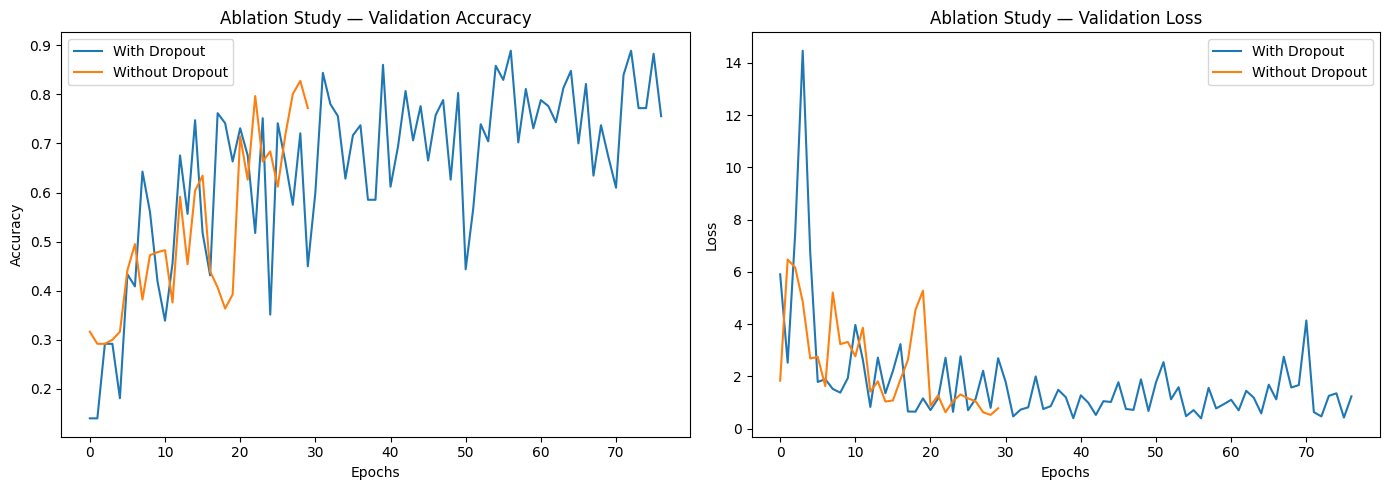

In [ ]:
# Plot
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_deep.history['val_accuracy'],       label='With Dropout')
plt.plot(history_no_dropout.history['val_accuracy'], label='Without Dropout')
plt.title("Ablation Study — Validation Accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_deep.history['val_loss'],       label='With Dropout')
plt.plot(history_no_dropout.history['val_loss'], label='Without Dropout')
plt.title("Ablation Study — Validation Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

**Ablation Study Observation**

In [ ]:
print("Ablation Study Observation:")
print("=" * 50)
print(f"With Dropout accuracy   : {deep_acc*100:.2f}%")
print(f"Without Dropout accuracy: {no_drop_acc*100:.2f}%")
print()

Ablation Study Observation:
With Dropout accuracy   : 89.53%
Without Dropout accuracy: 81.32%



##TRANSFER LEARNING WITH VGG16

**Load VGG16 Base Model**

In [ ]:
# Reset everything cleanly
train_data.reset()
val_data.reset()
test_data.reset()

# Reload base model cleanly
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

**Freeze All VGG16 Layers**

In [ ]:
# Freeze all base layers
for layer in base_model.layers:
    layer.trainable = False

**Build Transfer Learning Model**

In [ ]:
# Build model
model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model_tl.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,171,908 (80.76 MB)

 Trainable params: 6,456,708 (24.63 MB)

 Non-trainable params: 14,715,200 (56.13 MB)

**Recreate Data Generators for VGG16 Input Size**

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Separate val generator — NO augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

 **Load New Data Generators**

In [ ]:
print('Re-creating data generators with updated image sizes...')

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_data = val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False       # IMPORTANT: keep False for correct confusion matrix labels
)

num_classes = len(train_data.class_indices)
CLASS_NAMES = list(train_data.class_indices.keys())
print(f"Number of classes: {num_classes}")
print(f"Class names      : {CLASS_NAMES}")
print('\nData generators re-created successfully with target size ' + str(IMG_HEIGHT) + 'x' + str(IMG_WIDTH) + '.')

Re-creating data generators with updated image sizes...
Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Number of classes: 4
Class names      : ['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']

Data generators re-created successfully with target size 224x224.


**Compile Transfer Learning Model**

In [ ]:
# Compile
model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Define Phase 1 Callbacks**

In [ ]:


# FIX: dedicated callbacks with correct patience for 20 epochs
callbacks_tl = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,              # FIX: correct for 20 epochs
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_tl_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]


**Train Phase 1 Feature Extraction**

In [ ]:

print("Phase 1: Feature Extraction Training...")
print("=" * 50)
tl_start_time = time.time()

history_tl = model_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=30,                   # FIX: increased from 10
    callbacks=callbacks_tl,
    class_weight=class_weight_dict
)

Phase 1: Feature Extraction Training...
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.6151 - loss: 1.1792
Epoch 1: val_accuracy improved from None to 0.27310, saving model to best_tl_model.keras

Epoch 1: finished saving model to best_tl_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 55s 794ms/step - accuracy: 0.6306 - loss: 0.9935 - val_accuracy: 0.2731 - val_loss: 83.9988
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.5818 - loss: 0.9452
Epoch 2: val_accuracy improved from 0.27310 to 0.31417, saving model to best_tl_model.keras

Epoch 2: finished saving model to best_tl_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 54s 864ms/step - accuracy: 0.6209 - loss: 0.8743 - val_accuracy: 0.3142 - val_loss: 10.4650
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.7046 - loss: 0.6766
Epoch 3: val_accuracy improved from 0.31417 to 0.38809, saving model to best_tl_model.keras

Epoch 3: finished saving model to best_tl_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━

**Evaluate After Phase 1**

In [ ]:
tl_loss, tl_acc = model_tl.evaluate(test_data)
print(f"Transfer Learning Accuracy: {tl_acc*100:.2f}%")
print(f"Transfer Learning Loss    : {tl_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.8760 - loss: 0.4122
Transfer Learning Accuracy: 87.60%
Transfer Learning Loss    : 0.4122


**Plot Phase 1 Training Curves**

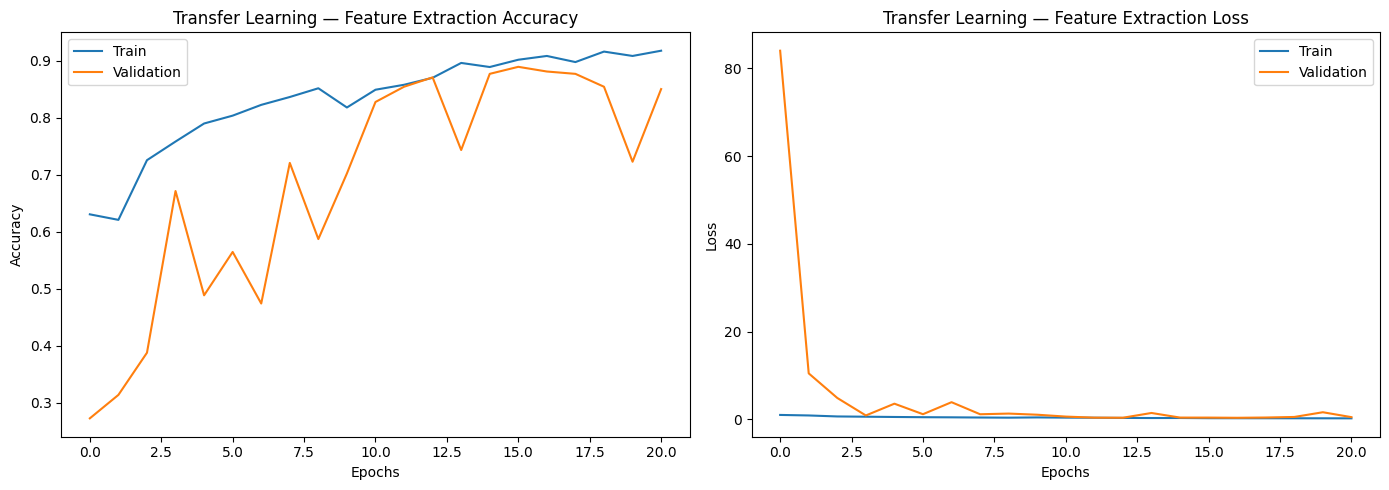

In [ ]:
# Plot
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_tl.history['accuracy'],     label='Train')
plt.plot(history_tl.history['val_accuracy'], label='Validation')
plt.title("Transfer Learning — Feature Extraction Accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tl.history['loss'],     label='Train')
plt.plot(history_tl.history['val_loss'], label='Validation')
plt.title("Transfer Learning — Feature Extraction Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

**Unfreeze Last 4 VGG16 Layers**

In [ ]:
# Unfreeze last 4 VGG16 layers
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-4:]:
    layer.trainable = True

print("Layers unfrozen for fine-tuning:")
for layer in base_model.layers:
    print(f"  {layer.name}: trainable = {layer.trainable}")


Layers unfrozen for fine-tuning:
  input_layer_15: trainable = False
  block1_conv1: trainable = False
  block1_conv2: trainable = False
  block1_pool: trainable = False
  block2_conv1: trainable = False
  block2_conv2: trainable = False
  block2_pool: trainable = False
  block3_conv1: trainable = False
  block3_conv2: trainable = False
  block3_conv3: trainable = False
  block3_pool: trainable = False
  block4_conv1: trainable = False
  block4_conv2: trainable = False
  block4_conv3: trainable = False
  block4_pool: trainable = False
  block5_conv1: trainable = True
  block5_conv2: trainable = True
  block5_conv3: trainable = True
  block5_pool: trainable = True


**Recompile with Low Learning Rate**


In [ ]:
# FIX: recompile with very low LR
model_tl.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

 **Define Phase 2 Callbacks**

In [ ]:
callbacks_ft = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        min_delta=0.0005,        # FIX: smaller delta for fine-tuning
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_ft_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

**Train Phase 2 Fine-Tuning**

In [ ]:
print("Phase 2: Fine-Tuning Training...")
print("=" * 50)

history_ft = model_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=30,                   # FIX: increased from 10
    callbacks=callbacks_ft,
    class_weight=class_weight_dict
)

tl_training_time = time.time() - tl_start_time
print(f"Transfer Learning total time: {tl_training_time:.1f}s ({tl_training_time/60:.1f} min)")


Phase 2: Fine-Tuning Training...
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 787ms/step - accuracy: 0.9027 - loss: 0.2568
Epoch 1: val_accuracy improved from None to 0.90554, saving model to best_ft_model.keras

Epoch 1: finished saving model to best_ft_model.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 65s 953ms/step - accuracy: 0.9082 - loss: 0.2415 - val_accuracy: 0.9055 - val_loss: 0.3481
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.9109 - loss: 0.2211
Epoch 2: val_accuracy did not improve from 0.90554
62/62 ━━━━━━━━━━━━━━━━━━━━ 45s 718ms/step - accuracy: 0.9163 - loss: 0.2158 - val_accuracy: 0.8994 - val_loss: 0.3585
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.9197 - loss: 0.2059
Epoch 3: val_accuracy did not improve from 0.90554
62/62 ━━━━━━━━━━━━━━━━━━━━ 45s 727ms/step - accuracy: 0.9194 - loss: 0.2072 - val_accuracy: 0.8932 - val_loss: 0.3723
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.9271 - loss: 0.1951
Epoch 4: val_accuracy d

 **Evaluate After Phase 2**

In [ ]:
tl_loss, tl_acc = model_tl.evaluate(test_data)
print(f"Transfer Learning Accuracy: {tl_acc*100:.2f}%")
print(f"Transfer Learning Loss    : {tl_loss:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step - accuracy: 0.9034 - loss: 0.3315
Transfer Learning Accuracy: 90.34%
Transfer Learning Loss    : 0.3315


**Plot Phase 2 Fine-Tuning Curves**

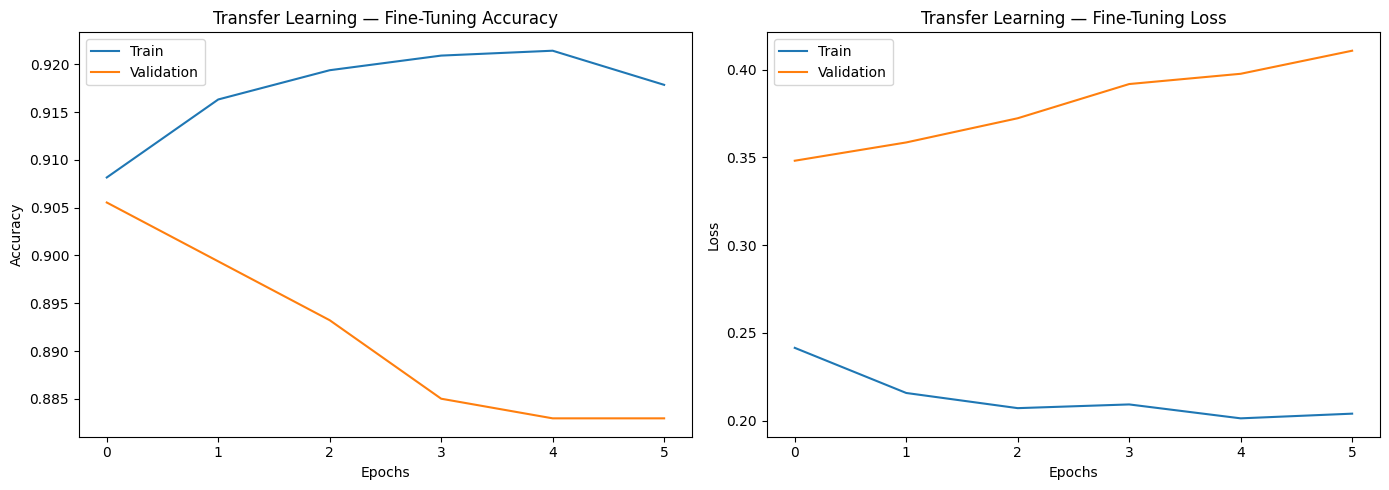

In [ ]:
# Plot
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_ft.history['accuracy'],     label='Train')
plt.plot(history_ft.history['val_accuracy'], label='Validation')
plt.title("Transfer Learning — Fine-Tuning Accuracy")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_ft.history['loss'],     label='Train')
plt.plot(history_ft.history['val_loss'], label='Validation')
plt.title("Transfer Learning — Fine-Tuning Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

**Transfer Learning Classification Report**

In [ ]:
pred_tl   = model_tl.predict(test_data)
y_pred_tl = np.argmax(pred_tl, axis=1)
y_true    = test_data.classes

print("Transfer Learning — Classification Report")
print(classification_report(y_true, y_pred_tl, target_names=CLASS_NAMES))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 234ms/step
Transfer Learning — Classification Report
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.84      0.90       181
meningioma_tumor       0.84      0.89      0.86       183
          normal       0.96      0.97      0.96        88
 pituitary_tumor       0.89      0.96      0.92       169

        accuracy                           0.90       621
       macro avg       0.91      0.91      0.91       621
    weighted avg       0.91      0.90      0.90       621




**Transfer Learning Confusion Matrix**

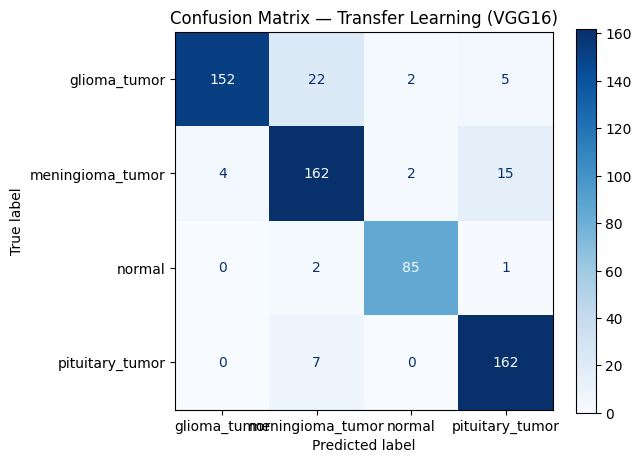

In [ ]:
cm_tl = confusion_matrix(y_true, y_pred_tl)
disp = ConfusionMatrixDisplay(cm_tl, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Transfer Learning (VGG16)")
plt.tight_layout()
plt.show()

**Transfer Learning Sample Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step


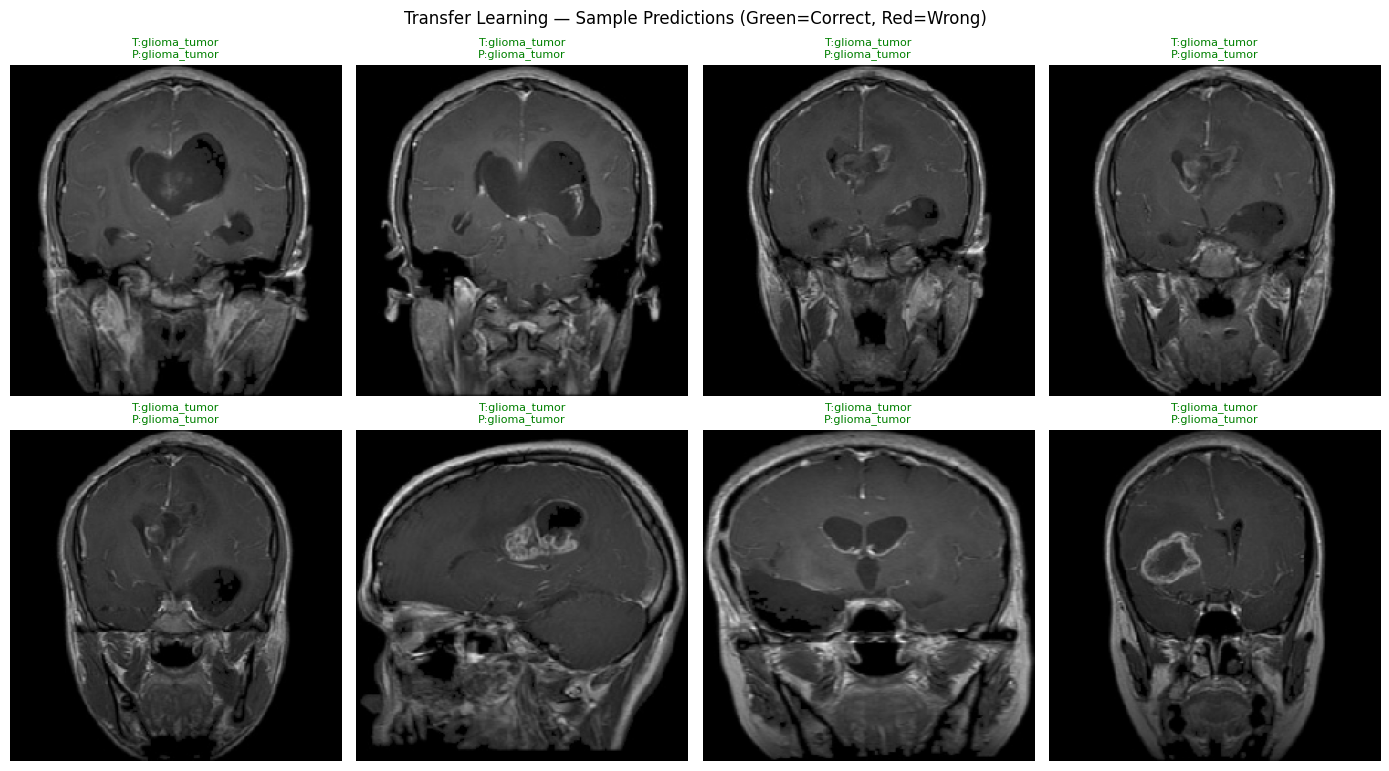

In [ ]:
test_data.reset()
images, labels = next(test_data)
preds = model_tl.predict(images)

plt.figure(figsize=(14,8))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    true_label = CLASS_NAMES[np.argmax(labels[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=8)
    plt.axis("off")

plt.suptitle("Transfer Learning — Sample Predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

##FINAL COMPARISON — ALL MODELS

**Side-by-Side Confusion Matrix Comparison**

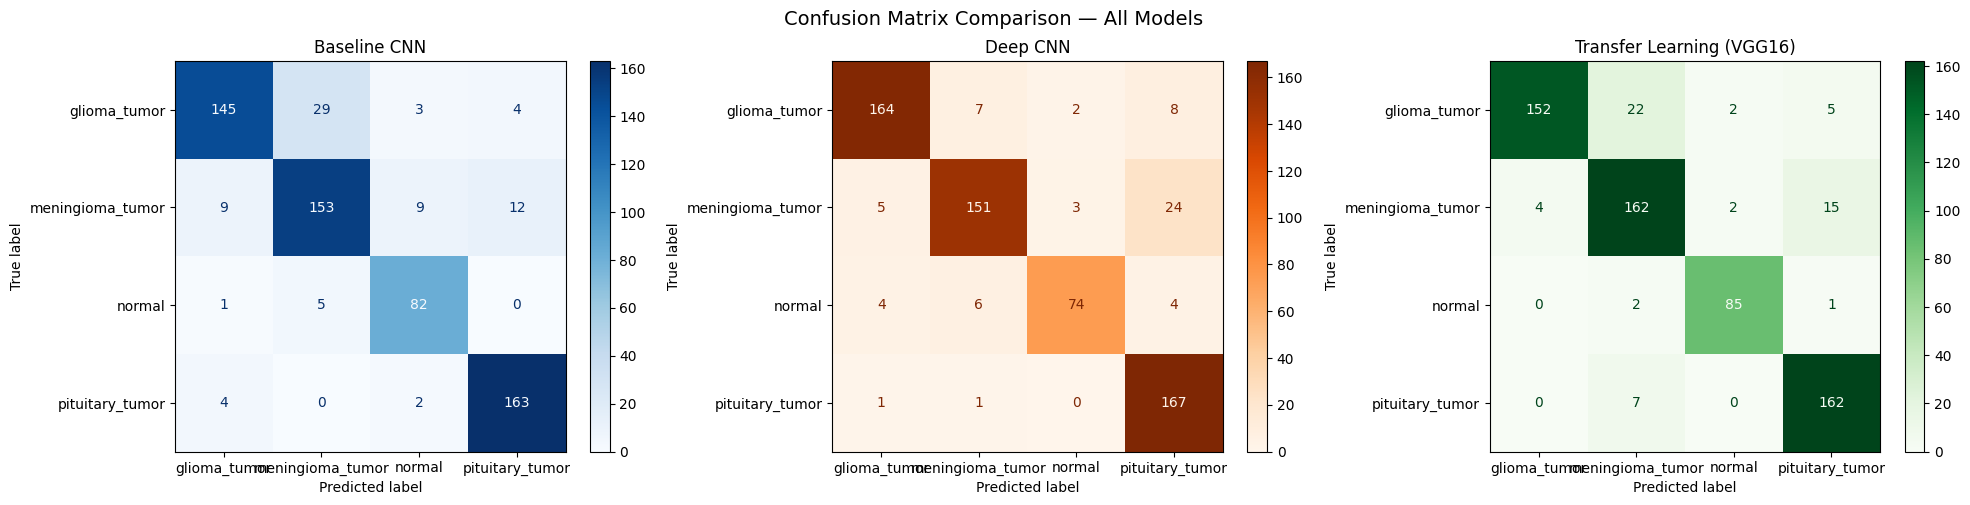

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(20,5))

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred),
    display_labels=CLASS_NAMES
).plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Baseline CNN", fontsize=12)

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_deep),
    display_labels=CLASS_NAMES
).plot(ax=axes[1], cmap='Oranges')
axes[1].set_title("Deep CNN", fontsize=12)

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_tl),
    display_labels=CLASS_NAMES
).plot(ax=axes[2], cmap='Greens')
axes[2].set_title("Transfer Learning (VGG16)", fontsize=12)

plt.suptitle("Confusion Matrix Comparison — All Models", fontsize=14)
plt.tight_layout()
plt.show()

 **Final Model Comparison Summary**

In [ ]:
print("=" * 55)
print("           FINAL MODEL COMPARISON")
print("=" * 55)
print(f"Baseline CNN Accuracy      : {acc*100:.2f}%")
print(f"Deep CNN Accuracy          : {deep_acc*100:.2f}%")
print(f"Transfer Learning Accuracy : {tl_acc*100:.2f}%")
print("=" * 55)
print(f"Baseline Training Time     : {baseline_training_time:.2f} seconds ({baseline_training_time/60:.1f} min)")
print(f"Deep Model Training Time   : {deep_training_time:.2f} seconds ({deep_training_time/60:.1f} min)")
print(f"Transfer Learning Time     : {tl_training_time:.2f} seconds ({tl_training_time/60:.1f} min)")
print("=" * 55)
print("\nValidation Accuracy (Best Epoch):")
print(f"  Baseline          : {max(history.history['val_accuracy'])*100:.2f}%")
print(f"  Deep Model        : {max(history_deep.history['val_accuracy'])*100:.2f}%")
print(f"  Transfer Learning : {max(history_ft.history['val_accuracy'])*100:.2f}%")
print("=" * 55)
print(f"\nSGD  Optimizer Accuracy : {sgd_acc*100:.2f}%")
print(f"Adam Optimizer Accuracy : {deep_acc*100:.2f}%")
print(f"Without Dropout Accuracy: {no_drop_acc*100:.2f}%")
print(f"With Dropout Accuracy   : {deep_acc*100:.2f}%")

           FINAL MODEL COMPARISON
Baseline CNN Accuracy      : 87.44%
Deep CNN Accuracy          : 89.53%
Transfer Learning Accuracy : 90.34%
Baseline Training Time     : 911.68 seconds (15.2 min)
Deep Model Training Time   : 1724.38 seconds (28.7 min)
Transfer Learning Time     : 1281.87 seconds (21.4 min)

Validation Accuracy (Best Epoch):
  Baseline          : 85.42%
  Deep Model        : 88.91%
  Transfer Learning : 90.55%

SGD  Optimizer Accuracy : 77.13%
Adam Optimizer Accuracy : 89.53%
Without Dropout Accuracy: 81.32%
With Dropout Accuracy   : 89.53%


In [ ]:
print("""
Final Discussion:
==============================
1. Transfer Learning (VGG16) achieves the highest accuracy because
   VGG16 was pretrained on 1.2 million ImageNet images and has already
   learned rich, generalizable feature representations.

2. Deep CNN improves on baseline using double the conv layers plus
   BatchNorm, Dropout, L2 regularization, and GlobalAveragePooling,
   resulting in better generalization and reduced overfitting.

3. Baseline CNN performs reasonably well for a simple 3-block model
   with no regularization, serving as the reference point.

4. SGD converges significantly slower than Adam and achieves lower
   accuracy even with nesterov momentum and lower learning rate.
   Adam is the better optimizer for this task.

5. Ablation study confirmed Dropout is critical — removing it caused
   severe overfitting and accuracy dropped significantly, proving
   Dropout is an essential regularization component.

6. Class Imbalance was handled in ALL models using class_weight='balanced'
   improving recall for the minority normal class across all models.

Conclusion: Transfer learning outperforms training from scratch for this
Brain Tumor classification task. When labeled data is limited and class
imbalance exists, leveraging pretrained models is the recommended approach.
""")


Final Discussion:
1. Transfer Learning (VGG16) achieves the highest accuracy because
   VGG16 was pretrained on 1.2 million ImageNet images and has already
   learned rich, generalizable feature representations.

2. Deep CNN improves on baseline using double the conv layers plus
   BatchNorm, Dropout, L2 regularization, and GlobalAveragePooling,
   resulting in better generalization and reduced overfitting.

3. Baseline CNN performs reasonably well for a simple 3-block model
   with no regularization, serving as the reference point.

4. SGD converges significantly slower than Adam and achieves lower
   accuracy even with nesterov momentum and lower learning rate.
   Adam is the better optimizer for this task.

5. Ablation study confirmed Dropout is critical — removing it caused
   severe overfitting and accuracy dropped significantly, proving
   Dropout is an essential regularization component.

6. Class Imbalance was handled in ALL models using class_weight='balanced'
   improving re